In [21]:
try:
    import keras
    import tensorflow
except:
    %pip install keras_preprocessing
    %pip install keras -qqq
    %pip install tensorflow -qqq
    %pip install pyserial -qqq
    %pip install matplotlib -qqq
    import keras
    import tensorflow
    import serial

In [22]:
from matplotlib import pyplot as plt
import numpy as np
from IPython.display import clear_output
import time
import random as rd


In [23]:
import serial
serial.Serial()

Serial<id=0x7f7c73b24250, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)

In [24]:
%pip install pyserial -qqq


Note: you may need to restart the kernel to use updated packages.


In [25]:
from keras_preprocessing import image as img

In [26]:
from PIL import Image

In [27]:
import socket
import numpy as np
import matplotlib.pyplot as plt
import struct

## Conjunto de funções dedicadas a comunicação TCP/IP - FreeRTOS

In [28]:
def connect_to_server(server_ip, server_port,string):
    """Establishes a connection to the server and returns the socket."""
    client_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    client_socket.connect((server_ip, server_port))
    #print(f"Connected to server at {server_ip}:{server_port} - {string}")
    #print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return client_socket
def send_message(client_socket, data):
    """Sends raw data to the server."""
    client_socket.sendall(data)

def receive_message(client_socket, data_size):
    """Receives raw data from the server."""
    data = client_socket.recv(data_size)  # Receive the data of the specified size
    #print("Received data.")
    return data

In [29]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
#        print(f'{bin(X[i][j])}',end=' ')

        print(f'{X[i][j]:01d}',end=' ')
    print()

In [30]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Bin[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*4**(BitsPorSimbolo))
      Ain[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*4**(BitsPorSimbolo))
  return [Ain,Bin]

In [31]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [32]:
def compar_matrix(M1,M2):
    for i in range(M1.shape[0]):
        for j in range(M1.shape[0]):
            if(M1[i][j]!=M2[i][j]):
                return 1
    return 0

In [33]:


def send2(Asyst,delay = 1/1000,string="none"):
    #print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here

    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =int(len(Asyst))        # Number of sine samples to send
    # Generate the sine wave (integer values)
    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT,string)
    # Send the sine wave data to the server (packed as binary)
    data_vec = Asyst
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    client_socket.close()


In [34]:
data_vec=[12,45]
struct.pack(f'<BB', *data_vec)

b'\x0c-'

In [35]:
data_vec=[12,11]
struct.pack(f'{2}i', *data_vec)

b'\x0c\x00\x00\x00\x0b\x00\x00\x00'

In [36]:
data_vec=[12,45]
struct.pack(f'<{2}i', *data_vec)

b'\x0c\x00\x00\x00-\x00\x00\x00'

In [37]:
bytearray([23])

bytearray(b'\x17')

In [38]:
def matrix2vec(m):
    lin = m.shape[0]
    col = m.shape[1]
    vec = np.zeros(lin*col,dtype=int)
    k= 0
    for i in range(lin):
        for j in range(col):
            vec[k] = int(m[i][j])
            k+=1
    return vec
def matrix2vec(m,m0):
    return np.array(np.concat(([255,255],m.reshape(1,31*16)[0][0:],[173,218,255,255],m0.reshape(1,31*16)[0][0:],[173,218])),dtype=np.int16)

vnstat -l -i enp4s0


In [39]:
def recever2A(col =16,delay = 1/1000,string="None"):
    #print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = col
    #print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =256        # Number of sine samples to send
    # Generate the sine wave (integer values)
    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT,string)
    data_vec = [0xea,0xea]
    data_vec_bytes = struct.pack(f'{2}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
    received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int32)
    client_socket.close()
    return received_data.reshape(16,16)



In [40]:
i = 0
while(True):
    A,B = np.array(create_matrix(16,1))
    Asyst ,Bsyst = shiftMatrixSystolic(A,B)
    vec = matrix2vec(Asyst.T,Bsyst.T)
    ti = time.time()
    send2(vec,delay = 0,string="OPA")
    time.sleep(500e-6)
    Y = recever2A(col =16,delay =0,string="A*B")
    tf = time.time()
    print(f"{(tf-ti)},{i}\n")
    time.sleep(500e-6)
    i+=1
    break


0.0016939640045166016,0



In [41]:
i = 0
while(True):
    A,B = np.array(create_matrix(16,1))
    Asyst ,Bsyst = shiftMatrixSystolic(A,B)
    vec = matrix2vec(Asyst.T,Bsyst.T)
    ti = time.time()
    send2(vec,delay = 0,string="OPA")
    time.sleep(8*144e-6)
    Y = recever2A(col =16,delay =0,string="A*B")
    i+=1
    tf = time.time()
    print((tf-ti),i,'\n')
    time.sleep(2*144e-6)
    break


 


0.0016376972198486328 1 



In [42]:
from keras.preprocessing.image import img_to_array

# Visão de escalabilidade e requisitos

In [43]:
sizt =128
sizek = 3
sizeSystolicCore = np.zeros(sizt)
sizeImagemProcessada = np.zeros(sizt)

#for i in range(sizek,sizt):
#    #(Imagem-1)**2==Systolic
#    sizeImagemProcessada[i-sizek] =i
#    sizeSystolicCore[i-sizek] = 2**(np.log2((i-sizek+1)**2))
#
#plt.figure(figsize=(10,10))
#desl = 7
#plt.yticks([2**(i+desl) for i in range(sizt-desl)])
#plt.stem(sizeImagemProcessada,sizeSystolicCore,markerfmt="^")
#plt.xlabel("Tamanho da Imagem")
#plt.ylabel("Requisito Systolic")

# FILTROS e IMAGEM

In [44]:
K1 = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
K1 = np.array([[1,1,1],[1,9,1],[1,1,1]])
#K1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
#K1 = np.array([[1,1,1],[1,1,1],[1,1,1]])/2
K2 = np.array([[-1,0,-1],[-2,0,2],[-1,0,1]])
#K1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
#K2=K1
M = np.array([[1,2,3,4],[4,5,6,4],[7,8,9,4],[3,6,0,1]])

M = np.array([[1,2,3],[4,5,6],[7,8,9]])
#K = np.array([[1,0],[0,-1]])
#K = np.array([[0,0],[0,1]])


In [45]:
path = "./Monalisa.webp"
image =plt.imread(path)

In [46]:

imga = img.load_img(
    path,
    target_size=(sizt,sizt),
    color_mode="grayscale",

)

In [47]:
image = imga.resize([sizt, sizt])



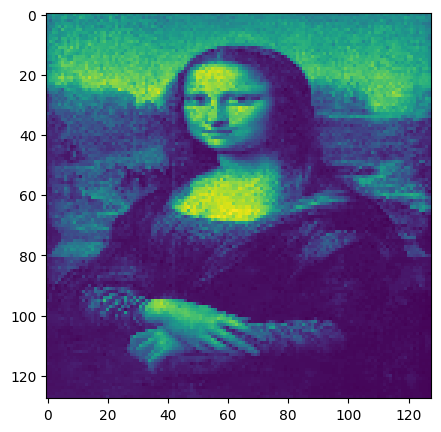

In [48]:
IMAG1 = img_to_array(image).reshape(sizt,sizt)
plt.figure(figsize=(5,5))
plt.imshow(IMAG1)
IMAG = M

In [49]:
def normalizeImage(image):
    size_row = image.shape[0]
    size_lin = image.shape[1]
    image_norm = np.zeros((size_lin,size_row),dtype=int)
    for i in range(size_lin):
        for j in range(size_row):
            if(image[i][j] > 32):
                image_norm[i][j] = 9
            else:
                image_norm[i][j] = 1
    return image_norm

In [50]:
max = IMAG1.max()

In [51]:
IMAG = np.array(((IMAG1)/max)*2**3,dtype=int)+1

In [52]:
IMAG.max()

np.int64(9)

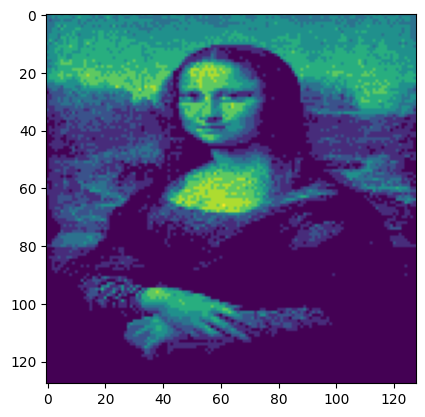

In [53]:
plt.imshow(IMAG)

In [54]:
IMAG

array([[4, 4, 5, ..., 4, 4, 4],
       [4, 4, 5, ..., 5, 4, 4],
       [4, 3, 4, ..., 5, 4, 4],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(128, 128))

In [55]:
def flatten_kernel(K):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada somente no kernel'''

    size = K.shape[0]
    outK = np.zeros((1,size**2))
    k = 0
    for i in range (size):
        for j in range(size):
        
            outK[0][k] = K[i][j]
            k+=1
    return outK

In [56]:
def inv_transform(M,sizeMinicial):
    "Inversão das transformações"
    size = int((sizeMinicial))
    Mout = np.zeros((size,size))
    print(size)

    k = 0
    for i in range(size):
        for j in range(size):
            Mout[i][j] = M[0][k]

            k+=1

    return Mout



In [57]:
def transform_matrix(M,Kern):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada matriz de entra'''
    sizeKernel  = Kern.shape[0] 
    sizel = M.shape[0]
    sizec = M.shape[1]
    Mout = np.zeros((sizeKernel**2,int((sizel-sizeKernel+1)**2)))
    k = 0
    for i in range(0,sizel-sizeKernel+1):
        for j in range(0,sizec-sizeKernel+1):
            '''Melhorias futuras'''
            X0 ,X1 ,X2 ,X3 ,X4 ,X5 ,X6 ,X7 ,X8 = M[i][j],M[i][j+1],M[i][j+2],M[i+1][j+0],M[i+1][j+1],M[i+1][j+2],M[i+2][j+0],M[i+2][j+1],M[i+2][j+2]
            Mout[0][k+0] = X0
            Mout[1][k+0] = X1
            Mout[2][k+0] = X2
            Mout[3][k+0] = X3
            Mout[4][k+0] = X4
            Mout[5][k+0] = X5
            Mout[6][k+0] = X6
            Mout[7][k+0] = X7
            Mout[8][k+0] = X8
            #X0 ,X1 ,X2 ,X3 = M[i][j],M[i][j+1],M[i+1][j],M[i+1][j+1]
            #Mout[0+0][k+0] = X0
            #Mout[0+1][k+0] = X1
            #Mout[0+2][k+0] = X2
            #Mout[0+3][k+0] = X3

            #print(X0,X1,X2,X3)
            k+=1
    return Mout

In [58]:
def normalizeMatrixSIZE(matrix,sizeTarget):
    matrixMout = np.zeros((sizeTarget,sizeTarget),dtype=int)
    size_row = matrix.shape[1]
    size_lin = matrix.shape[0]
    if(matrix.shape[0] ==1):
       # print("Kernel_transform detec")
       #Fazendo kernel**2 copias para maior deslocamneto no janelamento
        for i in range(size_row):
            for j in  range(size_row):
                matrixMout[0][j] = matrix[0][j]
                #matrixMout[i][j] = matrix[0][j]
                #print("Aqui",matrix[i][j])
    else:
        for i in range(size_lin):
            for j in  range(size_row):
                matrixMout[i][j] = matrix[i][j]
                #print("Aqui",matrix[i][j])
    return matrixMout
    


In [59]:
def conv2mult(sizeTarget, inputConv,inputK,debug='off'):
    '''Esta função realizá as transformações necessárias para converter a operação de convolução em uma multiplicação de matrizes'''
    Matrix_tranform = transform_matrix(inputConv,inputK)
    Kernel_transform = flatten_kernel(inputK)
    if(debug=='on'):
        print("Imagem new size:",Matrix_tranform.shape)
        print("Kernel new size:",Kernel_transform.shape)
    matrix_target_image=normalizeMatrixSIZE(matrix=Matrix_tranform,sizeTarget =sizeTarget)
    matrix_target_kernel=normalizeMatrixSIZE(matrix=Kernel_transform,sizeTarget=sizeTarget)
    return [matrix_target_kernel,matrix_target_image]

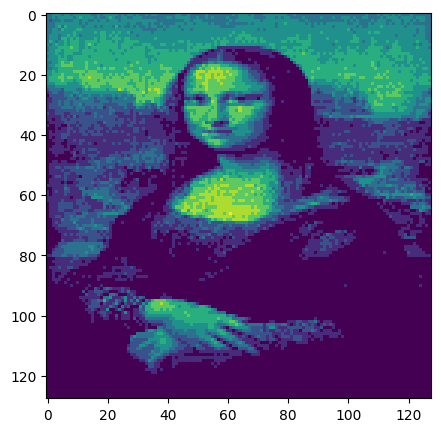

In [60]:
plt.figure(figsize=(5,5))
plt.imshow(IMAG)

In [61]:
def normalizeImage(image):
    size_row = image.shape[0]
    size_lin = image.shape[1]
    image_norm = np.zeros((size_lin,size_row),dtype=int)
    for i in range(size_lin):
        for j in range(size_row):
            if(image[i][j] > 4):
                image_norm[i][j] = 1
            else:
                image_norm[i][j] = 0
    return image_norm

In [62]:
#IMAG = normalizeImage(IMAG)

In [63]:
IMAG.max()

np.int64(9)

In [64]:
#plt.figure(figsize=(500,1000))
#plt.imshow(transform_matrix(IMAG,Kern=K).T)

In [65]:
requi = 2**int(np.log2((IMAG.shape[0]-sizek)**2)+1)
print("Requisito do multiplicador:", requi)

Requisito do multiplicador: 16384


In [66]:
#A1@B1

## Kernel no novo domínio com expansão dos operandos

In [67]:
#plt.subplot(1,2,1)
#plt.imshow(A1)
#plt.subplot(1,2,2)
#plt.imshow(A2)

## Imagem no novo domínio com expansão dos operandos


In [68]:
##@plt.subplot(1,2,1)
##@plt.imshow(B1)
##@plt.subplot(1,2,2)
##@plt.imshow(B2)


#Resultado da Convolução no novo domínio com expansão dos operandos

In [69]:
#plt.figure(figsize=(10,10))
#plt.subplot(1,2,1)
#plt.imshow(Mout_vec1)
#plt.subplot(1,2,2)
#plt.imshow(Mout_vec2)
#plt.show()

#Resultado da Convolução no domínio base

In [70]:
def windows_slice(imagem,windows_size,imag_size,step=3):

    '''Esta função retornará uma pequena fatia da imagem base, dada uma posição relativa. Com o tamanho da unidade de mulltiplicação'''
    window_buffer = np.zeros((windows_size,windows_size))
    
    try:
        for k in range(windows_size):
             for h in range(windows_size):
                window_buffer[k][h] = imagem[windows_slice.posy_static+k][windows_slice.posx_static+h]
    except:
        print("Fora do limite da imagem, posx e posy < imag_size")
        windows_slice.posx_static = 0
        windows_slice.posy_static = 0
    windows_slice.posx_static +=step
    if(windows_slice.posx_static >= imag_size-windows_size-step-1):
        windows_slice.posx_static = 0
        windows_slice.posy_static +=step
    print(windows_slice.posx_static,windows_slice.posy_static)
    return (window_buffer,windows_slice.posy_static == imag_size-windows_size-1)


In [71]:
windows_slice.posx_static = 0
windows_slice.posy_static = 0

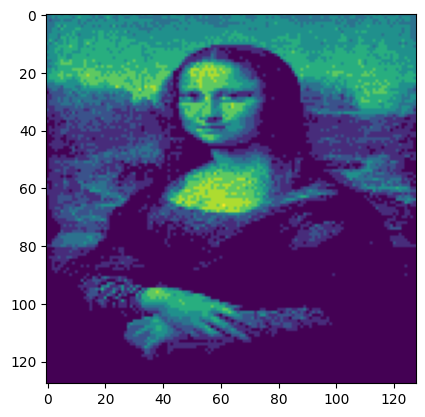

In [72]:
plt.imshow(IMAG)

In [73]:
windows_slice.posx_static = 0
windows_slice.posy_static = 0

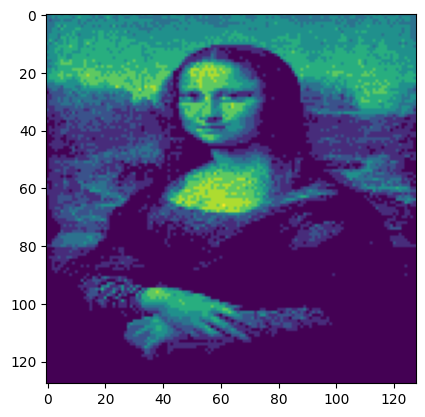

In [74]:
plt.imshow(IMAG)


In [75]:
def rebuild_image(windows_buffer_conv,size_imag,size_mult,windows_size,step=3):

    for k in range(size_mult):
     for h in range(size_mult):
        rebuild_image.window_buffer[rebuild_image.posy+k][rebuild_image.posx+h] = windows_buffer_conv[k][h]
    rebuild_image.posx +=step
    if(rebuild_image.posx >= size_imag-windows_size-step+2):
        
        if(rebuild_image.posx == size_mult and rebuild_image.posy == size_mult):
           rebuild_image.posy =size_mult
           rebuild_image.posy =size_mult
        else:   
            rebuild_image.posy +=step
            rebuild_image.posx  = 0

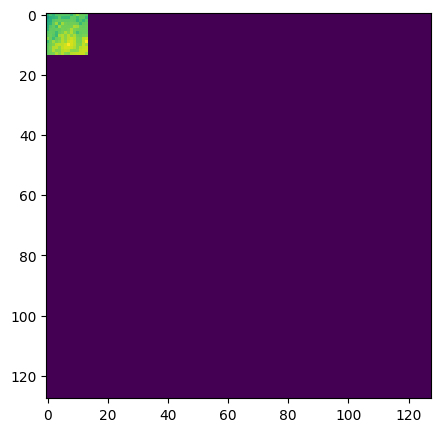

In [76]:
windows_size =16# Valor limite do Systolic da Arty A7
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
while(True):
    #time.sleep(1/30)
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
    A,B = conv2mult(sizeTarget=256,inputConv=windows_buffer,inputK=K1)
    ResultMult = A@B #ENtrada do SystolicCore-Arty A7 Limitada em 16x16-4Bit/Símbolo
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.imshow(windows_buffer_conv)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size)
    clear_output(wait=True)
    break #Retire
    if(finish ):
        break
    i+=1
plt.figure(figsize=(5,5))
plt.imshow(rebuild_image.window_buffer)
plt.show()

# Ambiente de convolução no PC

In [77]:
K1 = np.ones((3,3))
K1[0][0] = 1
K1[1][0] = 2
K1[2][0] = 1
K1[0][2] = -1
K1[1][2] = -2
K1[2][2] = -1
K1[0][1] = 0
K1[2][1] = 0
K1[1][1] = 0
K1=K1
K1

array([[ 1.,  0., -1.],
       [ 2.,  0., -2.],
       [ 1.,  0., -1.]])

In [78]:
while(True):
    break
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((8,8)))
    while(True):
        print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
        Asyst=abs(A)#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        ResultMult = Asyst@Bsyst
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        plt.subplot(1,2,1)
        plt.imshow(A)
        plt.subplot(1,2,2)

        plt.imshow(B)
        plt.show()
        print(windows_buffer_conv.shape,A.shape,B.shape)
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        clear_output(wait=True)
        if(finish ):
            break
        i+=1
        plt.figure(figsize=(10,10))
        plt.subplot(1,2,1)
        plt.imshow(rebuild_image.window_buffer)
        plt.subplot(1,2,2)
        plt.imshow(IMAG)
        plt.figure(figsize=(10,10))
        plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("kjhglsdgf")
            break
    break
    

In [79]:
while(True):
    break
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((8,8)))
    while(True):
        print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
        Asyst=abs(A)#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        ResultMult = Asyst@Bsyst
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        clear_output(wait=True)
        if(finish ):
            break
        i+=1
        plt.figure(figsize=(10,10))
        plt.subplot(1,2,1)
        plt.imshow(rebuild_image.window_buffer)
        plt.subplot(1,2,2)
        plt.imshow(IMAG)
        plt.figure(figsize=(10,10))
        plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("kjhglsdgf")
            break
    break
    

kjhglsdgf


<Figure size 800x800 with 0 Axes>

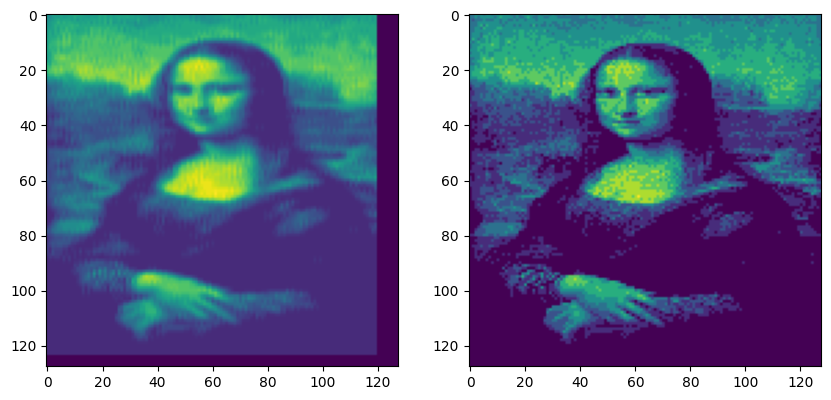

<Figure size 1000x1000 with 0 Axes>

finish


In [80]:
while(True):
   
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((8,8)))
    while(True):
        print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
        Asyst=abs(A)#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        ResultMult = Asyst@Bsyst
        #time.sleep(50e-6)
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        clear_output(wait=True)
        if(finish ):
            break
        i+=1
        if(False):
            plt.figure(figsize=(10,10))
            plt.subplot(1,2,1)
            plt.imshow(rebuild_image.window_buffer)
            plt.subplot(1,2,2)
            plt.imshow(IMAG)
            plt.figure(figsize=(10,10))
            plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("kjhglsdgf")
            break
    break

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(rebuild_image.window_buffer)
plt.subplot(1,2,2)
plt.imshow(IMAG)
plt.figure(figsize=(10,10))
plt.show()
if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
    print("finish")
    

# Ambiente de convolução na FPGA


In [81]:
K1[0][0] = 0
K1[1][0] = 0
K1[2][0] = 0
K1[0][2] = 0
K1[1][2] = 0
K1[2][2] = 0
K1[0][1] = 0
K1[2][1] = 0
K1[2][2] = 0
K1[1][1] = 1

In [82]:
K1

array([[0., 0., 0.],
       [0., 1., 0.],
       [0., 0., 0.]])

In [83]:
K1 = np.zeros((3,3))*1
K1[0][0] = -1 +8
K1[0][1] = -2 +8
K1[0][2] = -1 +8

K1[2][0] = 1+8
K1[2][1] = 2+8
K1[2][2] = 1+8

K1=K1
K1

array([[ 7.,  6.,  7.],
       [ 0.,  0.,  0.],
       [ 9., 10.,  9.]])

In [84]:
debug = False

In [85]:
cmap_list = list(plt.colormaps())
cmap_list

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

<Figure size 500x500 with 0 Axes>

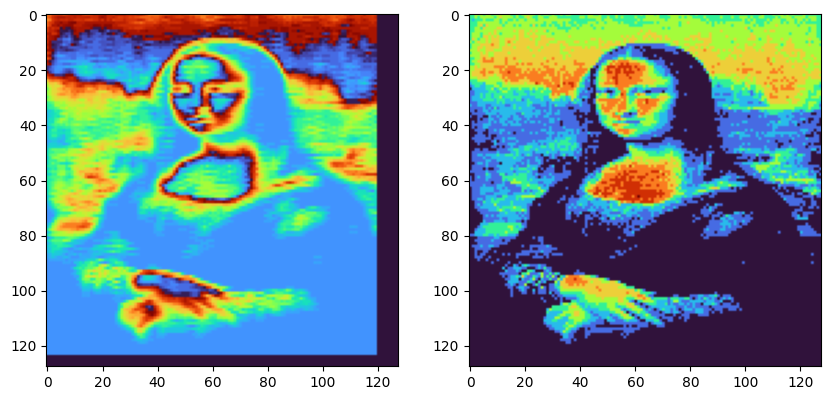

<Figure size 1000x1000 with 0 Axes>

4 0
4
8 0
4
12 0
4
16 0
4
20 0
4
24 0
4
28 0
4
32 0
4
36 0
4
40 0
4
44 0
4
48 0
4
52 0
4
56 0
4
60 0
4
64 0
4
68 0
4
72 0
4
76 0
4
80 0
4
84 0
4
88 0
4
92 0
4
96 0
4
100 0
4
104 0
4
108 0
4
112 0
4
116 0
4
0 4
4
4 4
4
8 4
4
12 4
4
16 4
4
20 4
4
24 4
4
28 4
4
32 4
4
36 4
4
40 4
4
44 4
4
48 4


KeyboardInterrupt: 

<Figure size 500x500 with 0 Axes>

In [92]:
plt.set_cmap('turbo')
while(True):
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((5,5)))
    k=0
    while(True):
        k+=1
        #print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='off')
        Asyst=abs(A)#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        M_p = shiftMatrixSystolic(Asyst,Bsyst)
        vec = matrix2vec(M_p[0].T,M_p[1].T)
        send2(vec,delay = 0,string="OPA")
        time.sleep(50e-6)
        ResultMult = recever2A(col =16,delay =0,string="A*B")
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        
        if(finish ):
            break
        i+=1
        if(i%((1024))==1 and debug):
            #print(windows_buffer_conv)
            clear_output(wait=True)
            plt.figure(figsize=(8,8))
            plt.subplot(1,2,1)
            plt.imshow(rebuild_image.window_buffer[0:windows_slice.posx_static][0:windows_slice.posy_static])
            #plt.imshow(rebuild_image.window_buffer,cmap="hot")
            plt.subplot(1,2,2)
            plt.imshow(IMAG)
            plt.figure(figsize=(8,8))
            
            plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("finish")
            break

    
    clear_output(wait=True)
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(rebuild_image.window_buffer)
    plt.subplot(1,2,2)
    plt.imshow(IMAG)
    plt.figure(figsize=(10,10))
    plt.show()
    
    #time.sleep(1)

    #1m26s
    #1m30s

# Ambiente de convolução no PC

In [ ]:
K1

array([[ 7.,  6.,  7.],
       [ 0.,  0.,  0.],
       [ 9., 10.,  9.]])

<Figure size 800x800 with 0 Axes>

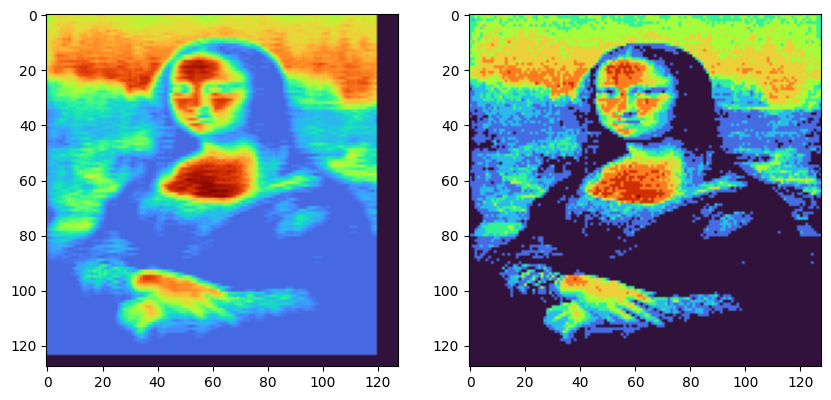

<Figure size 1000x1000 with 0 Axes>

In [ ]:
while(True):
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((8,8)))
    k=0
    while(True):
        k+=1
        #print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
        Asyst=abs(A)#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        M_p = shiftMatrixSystolic(Asyst,Bsyst)

        vec = matrix2vec(M_p[0].T,M_p[1].T)

        send2(vec,delay = 0,string="OPA")
        #send(M_p[0],delay = 1/fdelay,string="OPA")
        #time.sleep(2)
        #send(M_p[1],delay = 1/fdelay,string="OPB")
        time.sleep(50e-6)
        ResultMult = Asyst@Bsyst

        
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        #print(windows_buffer_conv)
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        
        if(finish ):
            break
        i+=1
        if(False):
            plt.figure(figsize=(10,10))
            plt.subplot(1,2,1)
            plt.imshow(rebuild_image.window_buffer)
            plt.subplot(1,2,2)
            plt.imshow(IMAG)
            plt.figure(figsize=(10,10))
            plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("finish")
            break


    
    clear_output(wait=True)
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(rebuild_image.window_buffer)
    plt.subplot(1,2,2)
    plt.imshow(IMAG)
    plt.figure(figsize=(10,10))
    plt.show()
    break
    #time.sleep(1)

    

In [ ]:
cmap_list = list(plt.colormaps())
cmap_list

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

In [ ]:
A,B = np.array(create_matrix(16,1))
Asyst ,Bsyst = shiftMatrixSystolic(A,B)
vec = matrix2vec(Asyst.T,Bsyst.T)
ti = time.time_ns()
send2(vec,delay = 0,string="OPA")
time.sleep(10e-6)
Y = recever2A(col =16,delay =0,string="A*B")
tf = time.time_ns()
print((tf-ti)*1e-9,'\n')
t_fpga = tf-ti



 


0.000681906 



In [ ]:
def software_mult(A,B,clock=333e+6):
    size = A.shape[0]
    C = np.zeros((size,size))
    for i in range(size):
        for j in range(size):
            sum_= 0
            for k in range(size):
                time.sleep(1/clock)
                sum_ += A[i][k]*B[k][j]
            C[i][j] = sum_
            #time.sleep(1/clock)
    return C

In [ ]:
A,B=create_matrix(16,1)



In [ ]:
software_mult(A,B,clock=333e+6);

In [ ]:
ti = time.time_ns()
software_mult(A,B,clock=333e+6);
tf = time.time_ns()
(tf-ti)*1e-9

0.20561056000000003

In [ ]:
ti = time.time_ns()
A@B;
tf = time.time_ns()
tf-ti

36368

In [ ]:
debug =False
A,B=create_matrix(16,2)
ti = time.time_ns()
if(debug):
    C = software_mult(A,B)
else:
    C=A@B
tf = time.time_ns()
t_pc = tf-ti
print(f"{t_fpga:}ns,  {t_pc:}ns,    {(t_pc/t_fpga)**(-1):}ns  {abs(t_fpga-t_pc)}")

681906ns,  36240ns,    18.816390728476822ns  645666


In [ ]:
A,B=create_matrix(128,1)

ti = time.time_ns()
C=A@B
tf = time.time_ns()
print(tf-ti)

1033771


In [ ]:
ping = [0.063,
0.065,
0.048,
0.063,
0.069,
0.070,
0.059,
0.057,
0.389,
0.062,
0.058,
0.059,
0.066,
0.064,
0.063,
0.055,
0.065,
0.048,
0.051,
0.064,
0.063,
0.059,
0.067,
0.061,
0.048,
0.053,
0.064,
0.059,
0.056,
0.059,
0.060,
0.056,
0.060,
0.070,
0.068,
0.067,
0.067,
0.065,
0.061,
0.067,
0.065,
0.065,
0.047,
0.060,
0.064,
0.056,
0.063,
0.063,
0.062,
0.064,
0.064,
0.056,
0.071,
0.075,
0.073,
0.056,
0.067,
0.068,
0.067,
0.403,
0.138,
0.057,
0.052,
0.065,
0.056,
0.067,
0.069,
0.065,
0.072,
0.076,
0.072,
0.071,
0.071,
0.069,
0.061,
0.076,
0.081,
0.076,
0.067,
0.073,
0.062,
0.073,
0.101,
0.073,
0.075,
0.066,
0.065,
0.052,
0.054,
0.064,
0.051,
0.056,
0.057,
0.071,
0.058,
0.073,
0.055,
0.063,
0.060,
0.066,
0.059,
0.089,
0.067,
0.064,
0.041,
0.059,
0.059,
0.060,
0.064,
0.065,
0.069,
0.061,
0.063,
0.059,
0.064,
0.070,
0.066,
0.073,
0.077,
0.059,
0.070,
0.061,
0.073,
0.059,
0.069,
0.068,
0.064,
0.064,
0.067,
0.066,
0.052,
0.061,
0.066,
0.052,
0.063,
0.059,
0.059,
0.068,
0.060,
0.068,
0.327,
0.064,
0.066,
0.071,
0.067,
0.048,
0.066,
0.067,
0.065,
0.050,
0.056,
0.068,
0.059,
0.072,
0.069,
0.064,
0.070,
0.071,
0.077,
0.065,
0.069,
0.074,
0.074,
0.065,
0.061,
0.065,
0.079,
0.063,
0.059,
0.057,
0.064,
0.064,
0.064,
0.066,
0.064,
0.051,
0.046,
0.064,
0.061,
0.048,
0.061,
0.081,
0.060,
0.065,
0.064,
0.065,
0.059,
0.060,
0.063,
0.057,
0.053,
0.057,
0.066,
0.060,
0.049,
0.065,
0.069,
0.058,
0.055,
0.073,
0.070,
0.061,
0.068,
0.055,
0.059,
0.071,
0.066,
0.083,
0.065,
0.055,
0.060,
0.061,
0.065,
0.051,
0.063,
0.064,
0.068,
0.071,
0.068,
0.062,
0.060,
0.062,
0.063,
0.057,
0.084,
0.047,
0.067,
0.058,
0.282,
0.060,
0.062,
0.065,
0.062,
0.085,
0.059,
0.062,
0.060,
0.062,
0.060,
0.054,
0.067,
0.067,
0.068,
0.051,
0.061,
0.068,
0.066,
0.067,
0.090,
0.068,
0.052,
0.062,
0.066,
0.059,
0.053,
0.064,
0.065,
0.060,
0.086,
0.060,
0.065,
0.061,
0.068,
0.058,
0.052,
0.064,
0.050,
0.056,
0.062,
0.053,
0.061,
0.056,
0.063,
0.056,
0.056,
0.065,
0.061,
0.065,
0.058,
0.069,
0.071,
0.061,
0.078,
0.078,
0.076,
0.069,
0.061,
0.071,
0.064,
0.068,
0.073,
0.071,
0.078,
0.072,
0.063,
0.050,
0.068,
0.077,
0.073,
0.067,
0.074,
0.066,
0.058,
0.071,
0.074,
0.057,
0.076,
0.059,
0.068,
0.071,
0.069,
0.071,
0.066,
0.067,
0.067,
0.065,
0.388,
0.062,
0.070,
0.056,
0.069,
0.062,
0.072,
0.048,
0.060,
0.072,
0.068,
0.069,
0.058,
0.060,
0.064,
0.062,
0.068,
0.052,
0.061,
0.065,
0.066,
0.061,
0.065,
0.062,
0.064,
0.062,
0.081,
0.065,
0.049,
0.058,
0.068,
0.058,
0.055,
0.046,
0.063,
0.050,
0.053,
0.061,
0.060,
0.062,
0.054,
0.058,
0.060,
0.061,
0.056,
0.059,
0.068,
0.062,
0.059,
0.062,
0.069,
0.057,
0.071,
0.073,
0.067,
0.065,
0.067,
0.059,
0.339,
0.051,
0.067,
0.069,
0.059,
0.066,
0.052,
0.053,
0.066,
0.083,
0.047,
0.062,
0.052,
0.064,
0.066,
0.054,
0.052,
0.064,
0.056,
0.060,
0.066,
0.059,
0.057,
0.046,
0.058,
0.066,
0.064,
0.063,
0.056,
0.056,
0.056,
0.064,
0.066,
0.062,
0.066,
0.068,
0.065,
0.060,
0.067,
0.066,
0.060,
0.066,
0.068,
0.055,
0.082,
0.065,
0.065,
0.057,
0.071,
0.058,
0.051,
0.076,
0.063,
0.047,
0.061,
0.061,
0.067,
0.052,
0.063,
0.077,
0.050,
0.051,
0.066,
0.057,
0.055,
0.059,
0.063,
0.058,
0.068,
0.055,
0.057,
0.065,
0.054,
0.061,
0.065,
0.058,
0.068,
0.054,
0.069,
0.064,
0.059,
0.068,
0.072,
0.066,
0.049,
0.070,
0.066,
0.057,
0.063,
0.063,
0.064,
0.050,
0.066,
0.060,
0.062,
0.051,
0.060,
0.056,
0.070,
0.059,
0.063,
0.060,
0.108,
0.063,
0.063,
0.063,
0.067,
0.062,
0.066,
0.278,
0.063,
0.054,
0.060,
0.055,
0.045,
0.069,
0.069,
0.054,
0.059,
0.073,
0.067,
0.069,
0.075,
0.059,
0.057,
0.073,
0.072,
0.071,
0.117,
0.061,
0.059,
0.062,
0.061,
0.063,
0.052,
0.070,
0.055,
0.068,
0.064,
0.061,
0.052,
0.041,
0.064,
0.061,
0.064,
0.067,
0.071,
0.061,
0.064,
0.064,
0.057,
0.048,
0.065,
0.063,
0.064,
0.051,
0.074,
0.055,
0.057,
0.058,
0.068,
0.071,
0.070,
0.068,
0.064,
0.072,
0.071,
0.073,
0.076,
0.061,
0.054,
0.065,
0.057,
0.059,
0.067,
0.069,
0.065,
0.061,
0.064,
0.048,
0.056,
0.047,
0.065,
0.061,
0.064,
0.044,
0.055,
0.061,
0.062,
0.064,
0.065,
0.062,
0.057,
0.063,
0.066,
0.054,
0.058,
0.061,
0.058,
0.065,
0.075,
0.074,
0.066,
0.060,
0.057,
0.068,
0.071,
0.070,
0.070,
0.066,
0.064,
0.063,
0.060,
0.058,
0.064,
0.068,
0.068,
0.066,
0.055,
0.067,
0.076,
0.060,
0.061,
0.058,
0.059,
0.046,
0.060,
0.061,
0.070,
0.062,
0.054,
0.059,
0.063,
0.059,
0.057,
0.065,
0.057,
0.063,
0.068,
0.054,
0.319,
0.069,
0.070,
0.063,
0.076,
0.065,
0.060,
0.074,
0.078,
0.063,
0.073,
0.076,
0.072,
0.066,
0.063,
0.065,
0.114,
0.063,
0.053,
0.046,
0.068,
0.066,
0.062,
0.058,
0.061,
0.063,
0.068,
0.063,
0.063,
0.058,
0.058,
0.057,
0.064,
0.053,
0.060,
0.061,
0.069,
0.058,
0.068,
0.053,
0.047,
0.061,
0.065,
0.059,
0.063,
0.065,
0.072,
0.069,
0.067,
0.065,
0.064,
0.066,
0.066,
0.064,
0.045,
0.065,
0.067,
0.063,
0.055,
0.058,
0.060,
0.064,
0.065,
0.047,
0.064,
0.056,
0.058,
0.059,
0.065,
0.066,
0.058,
0.068,
0.063,
0.059,
0.067,
0.062,
0.041,
0.055,
0.068,
0.058,
0.072,
0.058,
0.058,
0.051,
0.065,
0.072,
0.062,
0.076,
0.056,
0.064,
0.057,
0.058,
0.059,
0.051,
0.064,
0.058,
0.061,
0.067,
0.068,
0.067,
0.065,
0.067,
0.062,
0.067,
0.054,
0.058,
0.064,
0.060,
0.063,
0.077,
0.066,
0.299,
0.064,
0.055,
0.062,
0.067,
0.065,
0.067,
0.049,
0.067,
0.068,
0.069,
0.053,
0.063,
0.065,
0.076,
0.073,
0.073,
0.075,
0.075,
0.072,
0.061,
0.071,
0.072,
0.069,
0.065,
0.067,
0.065,
0.065,
0.064,
0.065,
0.054,
0.058,
0.064,
0.064,
0.064,
0.073,
0.055,
0.061,
0.058,
0.064,
0.066,
0.059,
0.065,
0.063,
0.063,
0.057,
0.063,
0.066,
0.064,
0.056,
0.072,
0.064,
0.062,
0.069,
0.061,
0.058,
0.069,
0.068,
0.060,
0.075,
0.068,
0.302,
0.053,
0.054,
0.067,
0.055,
0.067,
0.064,
0.068,
0.066,
0.068,
0.067,
0.061,
0.069,
0.061,
0.054,
0.064,
0.066,
0.064,
0.066,
0.065,
0.064,
0.060,
0.060,
0.055,
0.069,
0.062,
0.087,
0.062,
0.065,
0.064,
0.066]

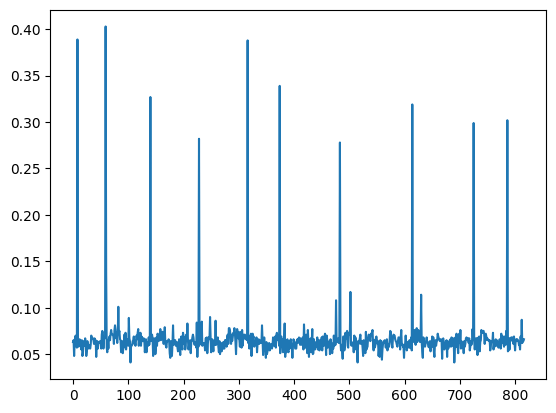

In [ ]:
plt.plot(ping)

In [ ]:
1/(ping[0]*1e-3)

15873.015873015873

In [273]:
#FPGA ciclos
clock= 333e+6
label = np.array(["IDLE ","MEMA ","MEMB ","SYSTOLIC ","PL_2_PS "])
contadores_FPGA = np.array([14,7456,7456,52,257])
contadores_SIMU = np.array([2,498,498,52,257])
tempo_FPGA = contadores_FPGA/clock
tempo_SIMU = contadores_SIMU/clock
total_FPGA=sum(contadores_FPGA)
total_SIMU=sum(contadores_SIMU)
percentual_de_tempo_FPGA = (contadores_FPGA/total_FPGA)*100
percentual_de_tempo_SIMU = (contadores_SIMU/total_SIMU)*100

In [656]:
total_FPGA/clock

np.float64(4.575075075075075e-05)

In [663]:
total_SIMU/clock
print(f'{total_SIMU/clock:e} {total_FPGA/clock:e}')

3.924925e-06 4.575075e-05


In [274]:
label

array(['IDLE ', 'MEMA ', 'MEMB ', 'SYSTOLIC ', 'PL_2_PS '], dtype='<U9')

In [172]:
tempo_FPGA

array([2.23903904e-05, 1.56156156e-07, 2.23903904e-05, 1.56156156e-07,
       7.71771772e-07, 4.20420420e-08])

(np.float64(-1.09999982598868),
 np.float64(1.0999979242306206),
 np.float64(-1.0999993298370458),
 np.float64(1.0999999680874784))

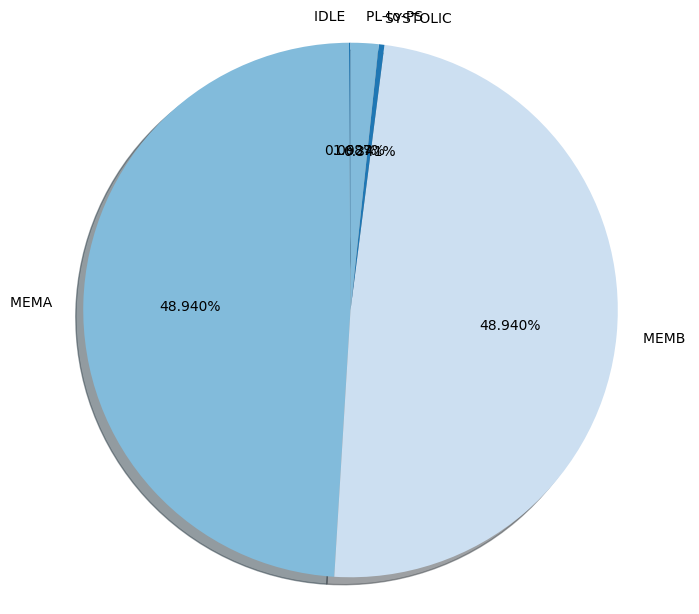

In [664]:
fig1,ax1=plt.subplots(figsize=(6,6))
ax1.pie(contadores_FPGA,labels=label,autopct='%.3f%%',shadow=True, startangle=90)
ax1.axis('equal')


In [443]:
label = np.array(["IDLE ","MEMA ","MEMB ","SYSTOLIC ","PL-to-PS "])


In [444]:
percentual_de_tempo_FPGA

array([ 0.09189367, 48.93994093, 48.93994093,  0.34131933,  1.68690515])

In [481]:
label1 = label
label1

array(['IDLE ', 'MEMA ', 'MEMB ', 'SYSTOLIC ', 'PL-to-PS '], dtype='<U9')

In [584]:
labelp_SIMU =[]
labelp_FPGA =[]
for i in range(len(label1)):
 labelp_SIMU.append(label[i]+(" "+str(f'{percentual_de_tempo_SIMU[i]:.3}'))+'%')
 labelp_FPGA.append(label[i]+(" "+str(f'{percentual_de_tempo_FPGA[i]:.3}'))+'%')

In [581]:
labelp_FPGA

['IDLE  0.153%',
 'MEMA  38.1%',
 'MEMB  38.1%',
 'SYSTOLIC  3.98%',
 'PL-to-PS  19.7%']

In [559]:
label1

array(['IDLE ', 'MEMA ', 'MEMB ', 'SYSTOLIC ', 'PL-to-PS '], dtype='<U9')

In [560]:
plt.cm.get_cmap

<function matplotlib.cm.get_cmap(name=None, lut=None)>

In [561]:
plt.get_cmap('magma')
plt.set_cmap('magma')

<Figure size 200x200 with 0 Axes>

In [641]:
tempo_SIMU

array([6.00600601e-09, 1.49549550e-06, 1.49549550e-06, 1.56156156e-07,
       7.71771772e-07])

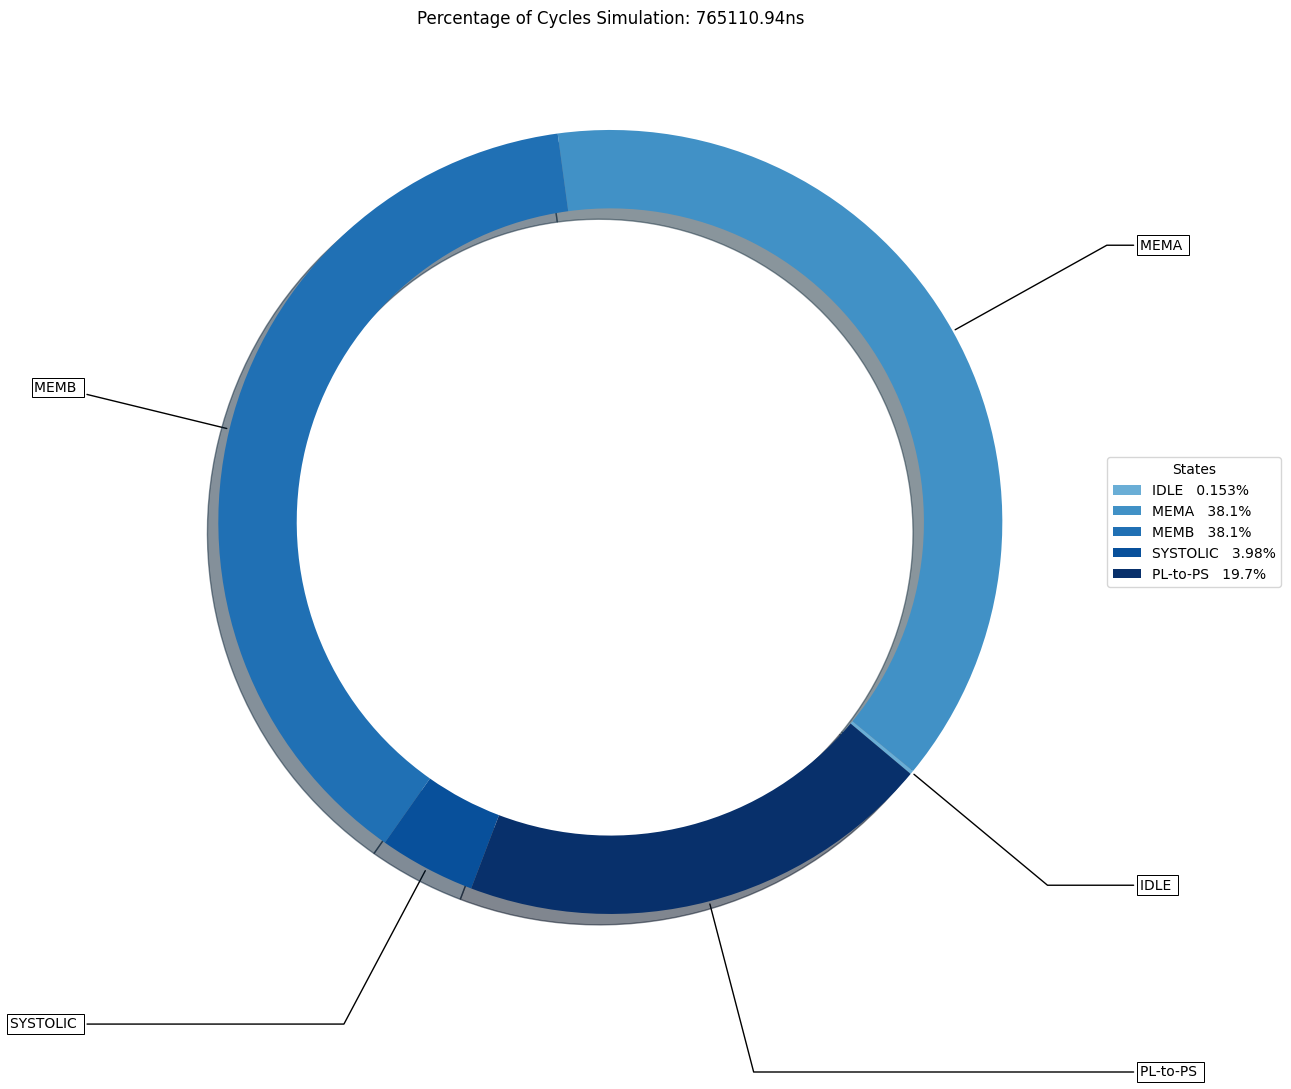

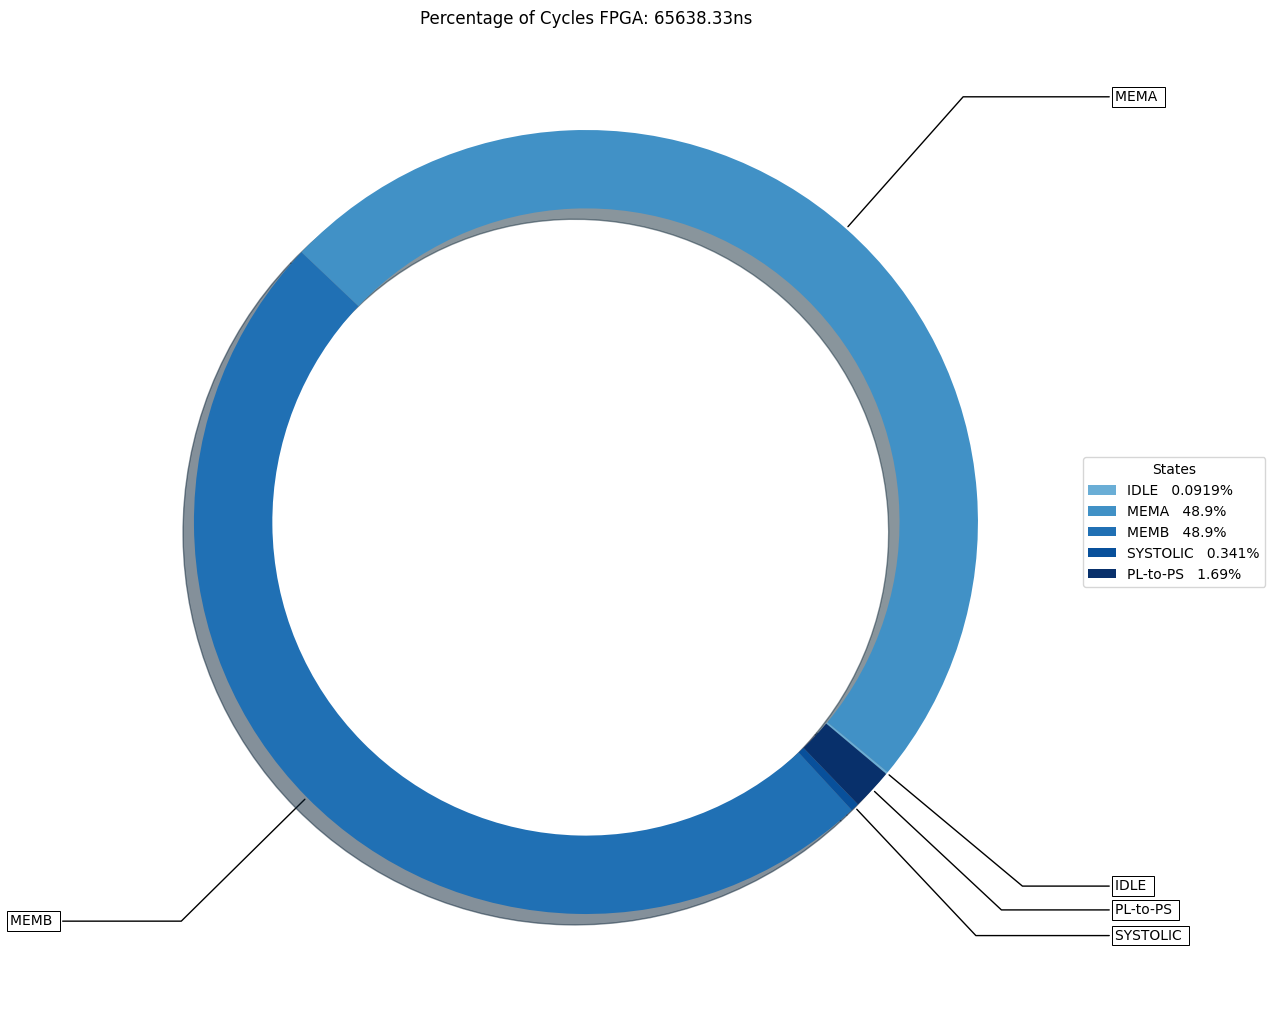

In [668]:
def plot_pie(label,Porcetagem,data,cmst0,cmst1,string,width):
    fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(aspect="equal"))

    recipe = label


    cmap= plt.cm.Blues
    #cmap= plt.cm.cool
    colors = {
    'blue':    '#377eb8', 
    'orange':  '#ff7f00',
    'green':   '#4daf4a',
    'pink':    '#f781bf',
    'brown':   '#a65628',
    'purple':  '#984ea3',
    'gray':    '#999999',
    'red':     '#e41a1c',
    'yellow':  '#dede00'
    }    
    colors = cmap(np.linspace(cmst0, cmst1, len(recipe)))

    wedges, texts = ax.pie(data, wedgeprops=dict(width=width), startangle=-40,colors=colors,shadow=True)

    bbox_props = dict(boxstyle="square,pad=0.2", fc="w", ec="k", lw=0.72)

    kw = dict(arrowprops=dict(arrowstyle="-"),
              bbox=bbox_props, zorder=0, va="center")

    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        ax.annotate(recipe[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.45*y),
                    horizontalalignment=horizontalalignment, **kw)

    ax.set_title("Percentage of Cycles "+string)
    labelp_SIMU = []
    for i in range(len(label1)):
        labelp_SIMU.append(label[i]+("  "+str(f'{Porcetagem[i]:.3}'))+'%')
    ax.legend(wedges, labelp_SIMU,
              title="States",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))
    plt.show()

plot_pie(label=label,Porcetagem=percentual_de_tempo_SIMU,data=contadores_SIMU,cmst0=.5,cmst1=1,string="Simulation: "+str(f"{(1/(total_SIMU))*1e+9:.2f}ns"),   width=.2)

plot_pie(label=label,Porcetagem=percentual_de_tempo_FPGA,data=contadores_FPGA,cmst0=.5,cmst1=1,string="FPGA: "+str(f"{(1/(total_FPGA))*1e+9:.2f}ns"),        width=.2)


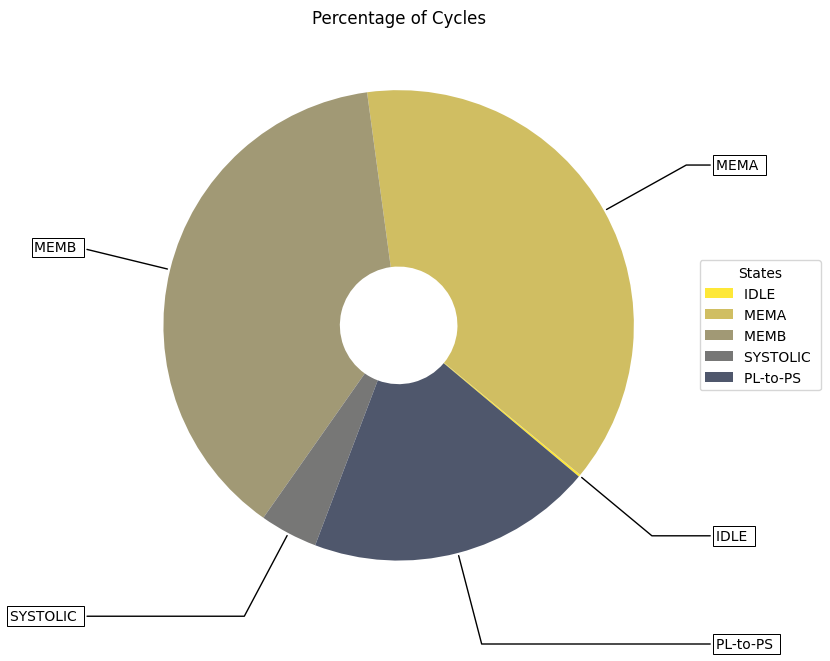

In [607]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(aspect="equal"))

recipe = label

data = contadores_SIMU
cmap = plt.cm.cividis
colors = cmap(np.linspace(1., .3, len(recipe)))
#colors =  plt.cm.Vega20c( (4./3*np.arange(20*3/4)).astype(int) )
wedges, texts = ax.pie(data, wedgeprops=dict(width=0.75), startangle=-40,colors=colors)

bbox_props = dict(boxstyle="square,pad=0.2", fc="w", ec="k", lw=0.72)

kw = dict(arrowprops=dict(arrowstyle="-"),
          bbox=bbox_props, zorder=0, va="center")

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    ax.annotate(recipe[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                horizontalalignment=horizontalalignment, **kw)

ax.set_title("Percentage of Cycles")
ax.legend(wedges, recipe,
          title="States",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

(np.float64(-1.0999948226931322),
 np.float64(1.0999990505154051),
 np.float64(-1.099997810197964),
 np.float64(1.0999998957237125))

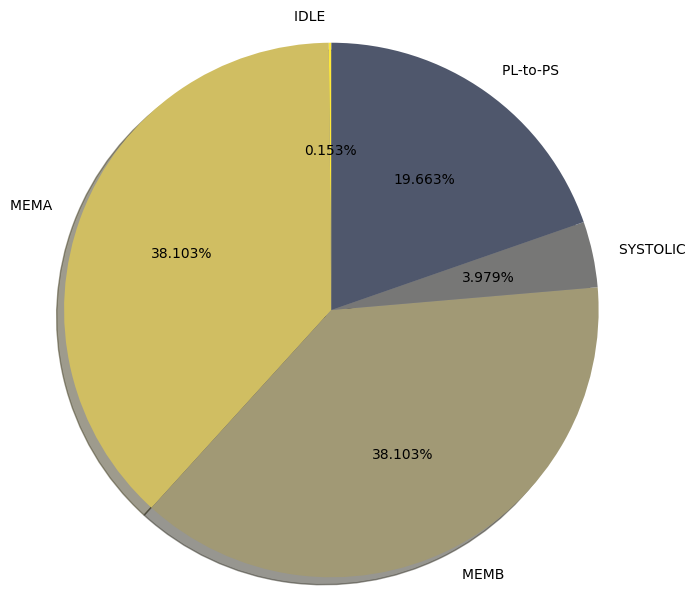

In [609]:
fig1,ax1=plt.subplots(figsize=(6,6))

cmap = plt.cm.cividis
colors = cmap(np.linspace(1., .3, len(recipe)))
ax1.pie(percentual_de_tempo_SIMU,labels=label,autopct='%.3f%%',shadow=True, startangle=90,colors=colors)
ax1.axis('equal')


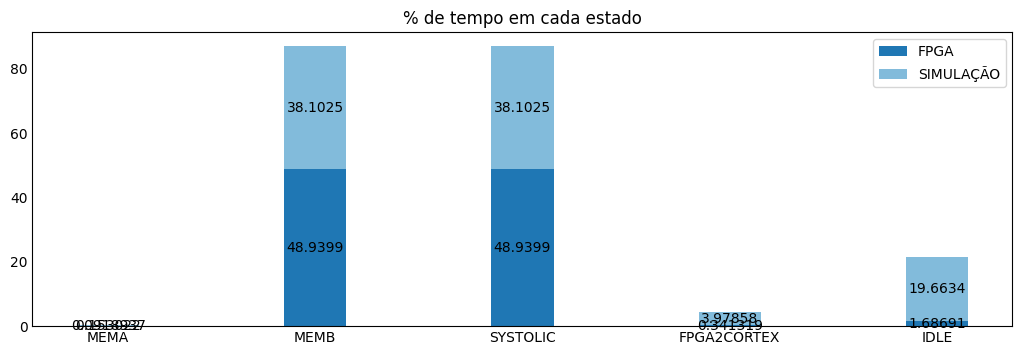

In [610]:
species = ("MEMA","MEMB","SYSTOLIC","FPGA2CORTEX","IDLE")
sex_counts = {
    'FPGA': percentual_de_tempo_FPGA,
    'SIMULAÇÃO': percentual_de_tempo_SIMU,
}
width = 0.3 # the width of the bars: can also be len(x) sequence


fig, ax = plt.subplots()
bottom = np.zeros(5)
fig.set_size_inches(10,3)
for sex, sex_count in sex_counts.items():
    p = ax.bar(species, sex_count, width, label=sex, bottom=bottom)
    bottom += sex_count

    ax.bar_label(p, label_type='center')

ax.set_title('% de tempo em cada estado')
ax.legend()

plt.show()

In [567]:
!pip install pandas

In [568]:
contadores_FPGA

array([  14, 7456, 7456,   52,  257])

In [569]:
def compose_time_vec(time_vec):
    time_t = np.zeros(6)
    time_t[0] = 0
    for i in range(1,6):
        time_t[i] = time_t[i-1]+time_vec[i-1]
    return time_t

In [570]:
ts = compose_time_vec(percentual_de_tempo_FPGA)
ts

array([0.00000000e+00, 9.18936659e-02, 4.90318346e+01, 9.79717755e+01,
       9.83130948e+01, 1.00000000e+02])

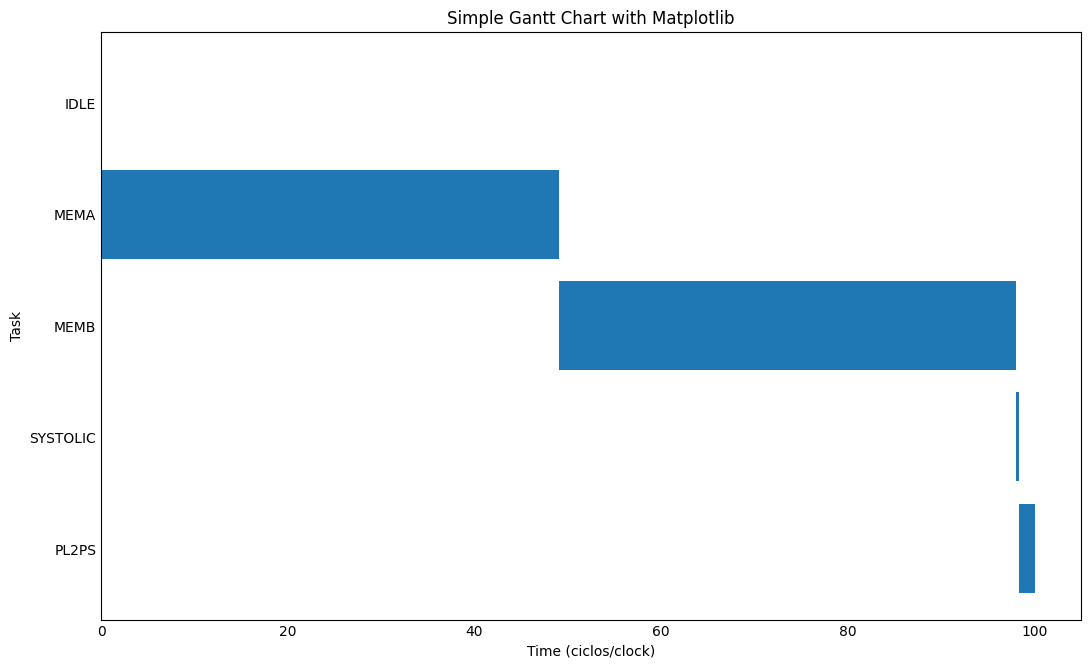

In [611]:
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt

# Sample Data

data = [
    {'Task': 'IDLE'     , 'Start': ts[0], 'End': ts[1]},
    {'Task': 'MEMA'     , 'Start': ts[1], 'End': ts[2]},
    {'Task': 'MEMB'     , 'Start': ts[2], 'End': ts[3]},
    {'Task': 'SYSTOLIC' , 'Start': ts[3], 'End': ts[4]},
    {'Task': 'PL2PS'    , 'Start': ts[4], 'End':ts[5]}
]
df = pd.DataFrame(data)
df['Start'] = (df['Start'])
df['End'] = (df['End'])

# Calculate duration and a numerical y-position
df['Duration'] = (df['End'] - df['Start'])
# Matplotlib works with numbers for plotting, so we convert dates to numerical values
# and set task names as the y-axis labels
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the horizontal bars
ax.barh(y=df['Task'], width=df['Duration'], left=df['Start'])

# Customize the chart
ax.set_xlabel('Time (ciclos/clock)')
ax.set_ylabel('Task')
ax.set_title('Simple Gantt Chart with Matplotlib')
ax.invert_yaxis() # Invert to have the first task at the top

# Format the x-axis to show dates correctly
#ax.xaxis_date()
#fig.autofmt_xdate() # Rotate and align date labels

plt.show()
